# Data Mining: Homework assignment (part 1)

Dependencies

In [2]:
%pip install seaborn
%pip install datasets
%pip install matplotlib
%pip install vaderSentiment
%pip install kneed
%pip install contractions
%pip install pyspellchecker
%pip install scikit-learn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated pa

For the csv files that this notebook creates, you can edit the number of max_rows below, to load as many rows from the datasets that you desire. We have tested the code on 1000, 10000 and 100000 lines, and the results are of course much better with a higher number of rows.  
We must however warn, that when max_rows exceeds values around 100000, it will require a lot of memory space(RAM) and is very likely to crash the jupyter kernel at the execution of some cell.

In [3]:
# limiting the csv to max_rows to work first
max_rows = 10000000
print('Datasets will be limited to', max_rows, 'rows')

Datasets will be limited to 10000000 rows


In [4]:
#########################################
###                                   ###
###           DATA FETCHING           ###
###                                   ###
#########################################
from datasets import load_dataset

print("Reviews:")

beauty_reviews = load_dataset("McAuley-Lab/Amazon-Reviews-2023", "raw_review_All_Beauty", split="full", streaming=True, trust_remote_code=True)
for row in beauty_reviews:
    print(row)
    break #print only the first row for testing.

appliances_reviews = load_dataset("McAuley-Lab/Amazon-Reviews-2023", "raw_review_Appliances", split="full", streaming=True, trust_remote_code=True)
for row in appliances_reviews:
    print(row)
    break #print only the first row for testing.

musical_instruments_reviews = load_dataset("McAuley-Lab/Amazon-Reviews-2023", "raw_review_Musical_Instruments", split="full", streaming=True, trust_remote_code=True)
for row in musical_instruments_reviews:
    print(row)
    break #print only the first row for testing.

software_reviews = load_dataset("McAuley-Lab/Amazon-Reviews-2023", "raw_review_Software", split="full", streaming=True, trust_remote_code=True)
for row in software_reviews:
    print(row)
    break #print only the first row for testing.

video_games_reviews = load_dataset("McAuley-Lab/Amazon-Reviews-2023", "raw_review_Video_Games", split="full", streaming=True, trust_remote_code=True)
for row in video_games_reviews:
    print(row)
    break #print only the first row for testing.


print("Meta data:")

beauty_meta = load_dataset("McAuley-Lab/Amazon-Reviews-2023", "raw_meta_All_Beauty", split="full", streaming=True, trust_remote_code=True)
for row in beauty_meta:
    print(row)
    break #print only the first row for testing.

appliances_meta = load_dataset("McAuley-Lab/Amazon-Reviews-2023", "raw_meta_Appliances", split="full", streaming=True, trust_remote_code=True)
for row in appliances_meta:
    print(row)
    break #print only the first row for testing.

musical_instruments_meta = load_dataset("McAuley-Lab/Amazon-Reviews-2023", "raw_meta_Musical_Instruments", split="full", streaming=True, trust_remote_code=True)
for row in musical_instruments_meta:
    print(row)
    break #print only the first row for testing.

software_meta = load_dataset("McAuley-Lab/Amazon-Reviews-2023", "raw_meta_Software", split="full", streaming=True, trust_remote_code=True)
for row in software_meta:
    print(row)
    break #print only the first row for testing.

video_games_meta = load_dataset("McAuley-Lab/Amazon-Reviews-2023", "raw_meta_Video_Games", split="full", streaming=True, trust_remote_code=True)
for row in video_games_meta:
    print(row)
    break #print only the first row for testing.


Reviews:
{'rating': 5.0, 'title': 'Such a lovely scent but not overpowering.', 'text': "This spray is really nice. It smells really good, goes on really fine, and does the trick. I will say it feels like you need a lot of it though to get the texture I want. I have a lot of hair, medium thickness. I am comparing to other brands with yucky chemicals so I'm gonna stick with this. Try it!", 'images': [], 'asin': 'B00YQ6X8EO', 'parent_asin': 'B00YQ6X8EO', 'user_id': 'AGKHLEW2SOWHNMFQIJGBECAF7INQ', 'timestamp': 1588687728923, 'helpful_vote': 0, 'verified_purchase': True}
{'rating': 5.0, 'title': 'Work great', 'text': 'work great. use a new one every month', 'images': [], 'asin': 'B01N0TQ0OH', 'parent_asin': 'B01N0TQ0OH', 'user_id': 'AGKHLEW2SOWHNMFQIJGBECAF7INQ', 'timestamp': 1519317108692, 'helpful_vote': 0, 'verified_purchase': True}
{'rating': 5.0, 'title': 'Five Stars', 'text': 'Great headphones, comfortable and sound is good. No complaints. I would buy again.', 'images': [], 'asin': 'B

In [5]:
# Our 5 categories in a list for easy access
categories = ["appliances", "beauty", "musical_instruments", "software", "video_games"]

# debugging
# categories = ["appliances"]

Creating the CSV files from streaming, with, only the necessary lines until max_rows.

In [5]:
# CSV creation

import csv
import os

# data_dict is one of the two dictionairies reviews/meta_data
# data_type is either "reviews" or "meta"
# max_rows is the number of rows to be written in the csv file
def write_csv_files(data_dict, data_type, max_rows):
    first_category = next(iter(data_dict))
    for first_row in data_dict[first_category]:
        columns = list(first_row.keys())
        break
    for category, data in data_dict.items():
        if not data:
            print(f"No data for {category} {data_type}")
            continue
        filename = f"./{category}_{data_type}.csv"
        print(f"Writing {category}_{data_type}.csv...")
        try:
            with open(filename, "w", newline="", encoding="utf-8") as file:
                writer = csv.writer(file, escapechar='\\')
                writer.writerow(columns)
                count = 0
                for row in data:
                    if count >= max_rows:
                        break
                    csv_row = [row.get(col, "") for col in columns]
                    writer.writerow(csv_row)
                    count += 1
            print(f"Finished writing {filename} with {count} rows")
        except Exception as e:
            print(f"Error writing {filename}: {e}")


reviews = {
    "appliances": appliances_reviews,
    "beauty": beauty_reviews,
    "musical_instruments": musical_instruments_reviews,
    "software": software_reviews,
    "video_games": video_games_reviews
}

meta_data = {
    "appliances": appliances_meta,
    "beauty": beauty_meta,
    "musical_instruments": musical_instruments_meta,
    "software": software_meta,
    "video_games": video_games_meta
}

write_csv_files(reviews, "reviews", max_rows)
write_csv_files(meta_data, "meta", max_rows)





# The lines below produce the same result. They aren't optimal because,
# they fetch the whole dataset first and then only keep the max_rows whereas
# with the method above, we are able to fetch and create the csv files with
# the necessary lines only("max_rows"). And this is why it isn't preferred.


# pd.DataFrame(appliances_reviews).head(max_rows).to_csv("appliances_reviews.csv", index=False)
# pd.DataFrame(beauty_reviews).head(max_rows).to_csv("beauty_reviews.csv", index=False)
# pd.DataFrame(musical_instruments_reviews).head(max_rows).to_csv("musical_instruments_reviews.csv", index=False)
# pd.DataFrame(software_reviews).head(max_rows).to_csv("software_reviews.csv", index=False)
# pd.DataFrame(video_games_reviews).head(max_rows).to_csv("video_games_reviews.csv", index=False)

# pd.DataFrame(appliances_meta).head(max_rows).to_csv("appliances_meta.csv", index=False)
# pd.DataFrame(beauty_meta).head(max_rows).to_csv("beauty_meta.csv", index=False)
# pd.DataFrame(musical_instruments_meta).head(max_rows).to_csv("musical_instruments_meta.csv", index=False)
# pd.DataFrame(software_meta).head(max_rows).to_csv("software_meta.csv", index=False)
# pd.DataFrame(video_games_meta).head(max_rows).to_csv("video_games_meta.csv", index=False)

Writing appliances_reviews.csv...
Finished writing ./appliances_reviews.csv with 2128605 rows
Writing beauty_reviews.csv...
Finished writing ./beauty_reviews.csv with 701528 rows
Writing musical_instruments_reviews.csv...
Finished writing ./musical_instruments_reviews.csv with 3017439 rows
Writing software_reviews.csv...
Finished writing ./software_reviews.csv with 4880181 rows
Writing video_games_reviews.csv...
Finished writing ./video_games_reviews.csv with 4624615 rows
Writing appliances_meta.csv...
Finished writing ./appliances_meta.csv with 94327 rows
Writing beauty_meta.csv...
Finished writing ./beauty_meta.csv with 112590 rows
Writing musical_instruments_meta.csv...
Finished writing ./musical_instruments_meta.csv with 213593 rows
Writing software_meta.csv...
Finished writing ./software_meta.csv with 89251 rows
Writing video_games_meta.csv...
Finished writing ./video_games_meta.csv with 137269 rows


Dataframes from CSVs

In [6]:
import pandas as pd

# We need two dictionaries, one for reviews dataframes, one for meta dataframes
reviews_dfs = {}
meta_dfs = {}
for category in categories:
    reviews_csv_file = f"./{category}_reviews.csv"
    meta_csv_file = f"./{category}_meta.csv"
    reviews_dfs[category] = pd.read_csv(reviews_csv_file)
    meta_dfs[category] = pd.read_csv(meta_csv_file)
    print(f"Created dataframes for {category}")


/tmp/ipykernel_7831/3641640359.py:10: DtypeWarning: Columns (14,15) have mixed types. Specify dtype option on import or set low_memory=False.
  meta_dfs[category] = pd.read_csv(meta_csv_file)


Created dataframes for appliances
Created dataframes for beauty
Created dataframes for musical_instruments
Created dataframes for software
Created dataframes for video_games


### Task 1: Dataset Preparation

We're starting off with some basic preprocessing and normalization of the dataset. When doing wordclouds we noticed that a lot of HTML elements would show up, so we are removing HTML elements from the review texts. Another issue were the missing values for the price column, in the metadata datasets. We can't have "None" values for fileds as important as prices, so we decided to replace "None" price values, with the mean price of the whole dataset.

In [7]:
###########################################
###                                     ###
###       HANDLING MISSING VALUES       ###
###                                     ###
###########################################

def display_number_of_null(df):
    columns = [
        'price', 'average_rating', 'rating_number', 'features',
        'description', 'images', 'videos', 'store', 'categories',
        'details', 'parent_asin', 'bought_together', 'subtitle', 'author'
    ]

    for col in columns:
        col_sum = df[col].isnull().sum()
        print(f"Column \"{col}\" has {col_sum} null values")
    print("\n")

for category, df in meta_dfs.items():
    text = f" {category} "
    pad = 40 - len(text)
    left = pad // 2
    right = pad - left
    print("=" * left + text + "=" * right)
    display_number_of_null(df)


def get_mean_price_from_df(df):
    # converts column price to numbers, and non-numerics to NaN
    df['price'] = pd.to_numeric(df['price'], errors='coerce')
    return df['price'].mean()

for category in categories:
    if category == "appliances":
        appliances_mean = get_mean_price_from_df(meta_dfs[category])
        print(f'The average product price in category "{category}" is', appliances_mean)
    if category == "beauty":
        beauty_mean = get_mean_price_from_df(meta_dfs[category])
        print(f'The average product price in category "{category}" is', beauty_mean)
    if category == "musical_instruments":
        musical_instruments_mean = get_mean_price_from_df(meta_dfs[category])
        print(f'The average product price in category "{category}" is', musical_instruments_mean)
    if category == "software":
        software_mean = get_mean_price_from_df(meta_dfs[category])
        print(f'The average product price in category "{category}" is', software_mean)
    if category == "video_games":
        video_games_mean = get_mean_price_from_df(meta_dfs[category])
        print(f'The average product price in category "{category}" is', video_games_mean)

        

============== appliances ==============
Column "price" has 47601 null values
Column "average_rating" has 0 null values
Column "rating_number" has 0 null values
Column "features" has 0 null values
Column "description" has 0 null values
Column "images" has 0 null values
Column "videos" has 0 null values
Column "store" has 927 null values
Column "categories" has 0 null values
Column "details" has 0 null values
Column "parent_asin" has 0 null values
Column "bought_together" has 94327 null values
Column "subtitle" has 94322 null values
Column "author" has 94326 null values


================ beauty ================
Column "price" has 94886 null values
Column "average_rating" has 0 null values
Column "rating_number" has 0 null values
Column "features" has 0 null values
Column "description" has 0 null values
Column "images" has 0 null values
Column "videos" has 0 null values
Column "store" has 11344 null values
Column "categories" has 0 null values
Column "details" has 0 null values
Column "

In [8]:
def replace_invalid_prices(df, mean):
    df['price'] = pd.to_numeric(df['price'], errors='coerce') # coerce replaces any non-numeric value with NaN
    # locates the rows that have bad 'price' value and replaces the 'price' in these rows with the mean value provided
    df.loc[(df['price'].isna()) | (df['price'] <= 0.0), 'price'] = mean
    return df

# replacing all bad values with the mean value of the rest
for category in categories:
    if category == "appliances":
        replace_invalid_prices(meta_dfs['appliances'], appliances_mean)
    if category == "beauty":
        replace_invalid_prices(meta_dfs['beauty'], beauty_mean)
    if category == "musical_instruments":
        replace_invalid_prices(meta_dfs['musical_instruments'], musical_instruments_mean)
    if category == "software":
        replace_invalid_prices(meta_dfs['software'], software_mean)
    if category == "video_games":
        replace_invalid_prices(meta_dfs['video_games'], video_games_mean)

# these should be now zero
for category in categories:
    df_nulls = (meta_dfs[category])['price'].isnull().sum()
    print(f"{df_nulls}")

0
0
0
0
0


In [9]:
###########################################
###                                     ###
###         TEXT PREPROCESSING          ###
###                                     ###
###########################################

def clean_text(df):
    df["text"] = df["text"].str.replace(r'<.*?>', '', regex=True) # removing html elements

    # more in part 2, for now we don't need anything else

    return df

for category in categories:
    reviews_dfs[category] = clean_text(reviews_dfs[category])

### Task 1: Ratings and Reviews

/home/fanisbar/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


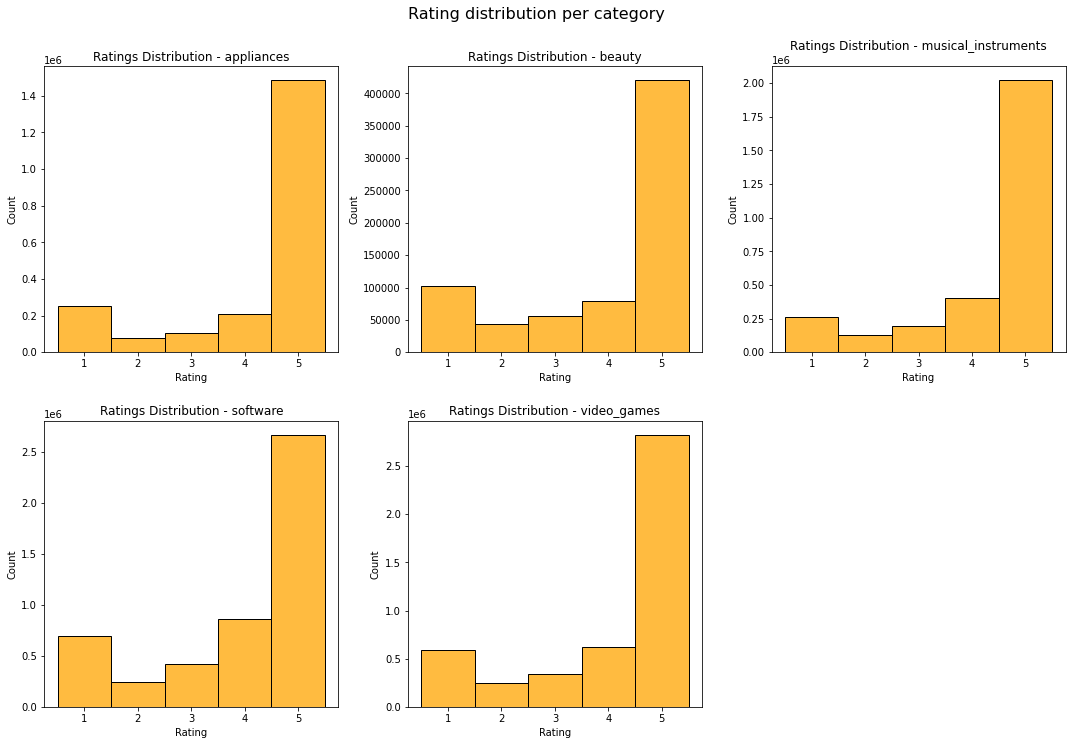

In [10]:
# Visualization of rating distribution throughout the datasets

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 10))

i = 1
for category, df in reviews_dfs.items():
    plt.subplot(2, 3, i)
    sns.histplot(df['rating'], bins=5, kde=False, discrete=True, color='orange')
    plt.title(f"Ratings Distribution - {category}")
    plt.xlabel("Rating")
    plt.ylabel("Count")
    plt.xticks([1, 2, 3, 4, 5])
    i += 1

plt.tight_layout()
plt.suptitle("Rating distribution per category", fontsize=16, y=1.03)
plt.show()


########################################
##   Category: appliances
########################################



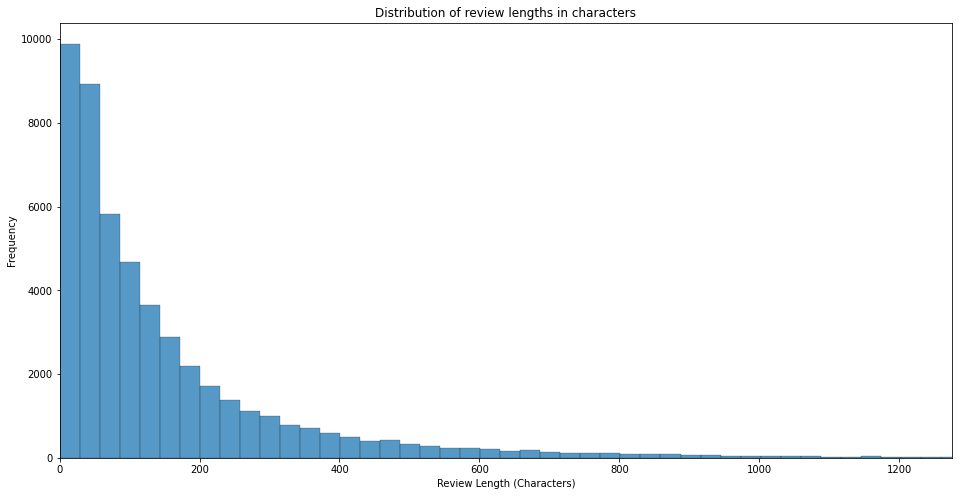

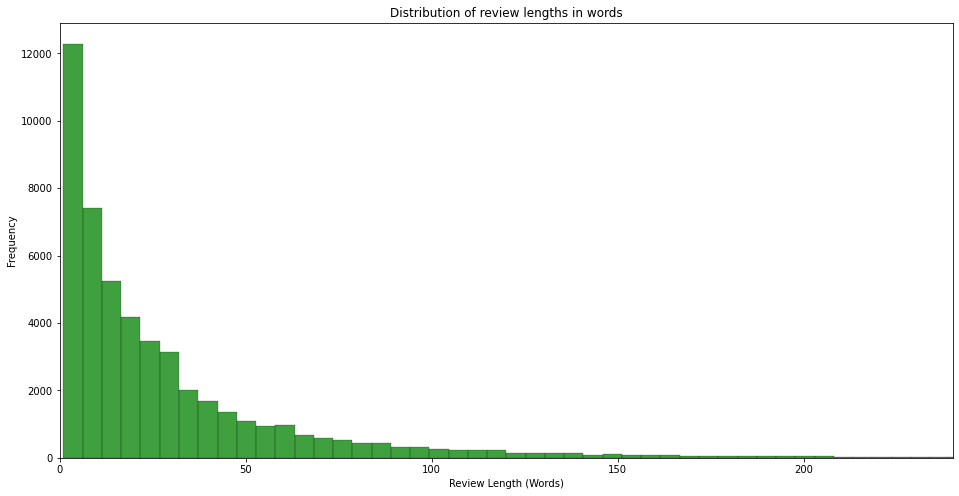

########################################
##   Category: beauty
########################################



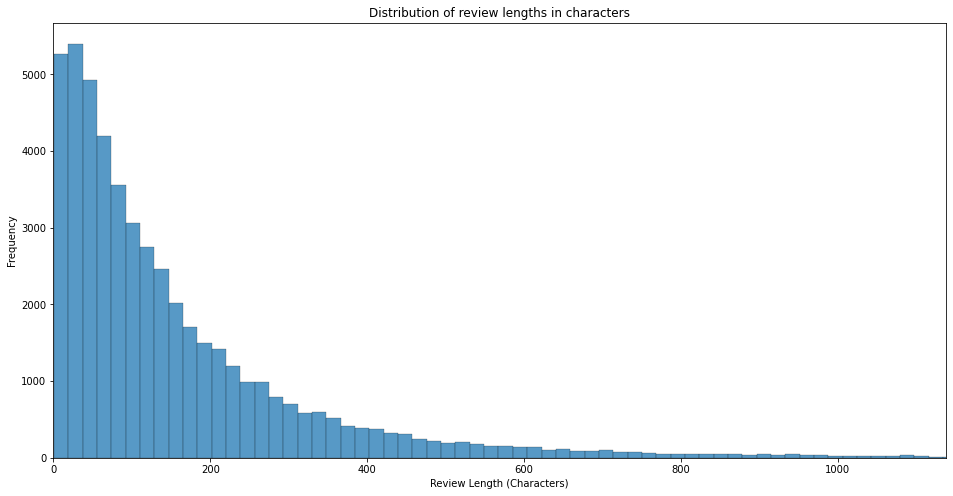

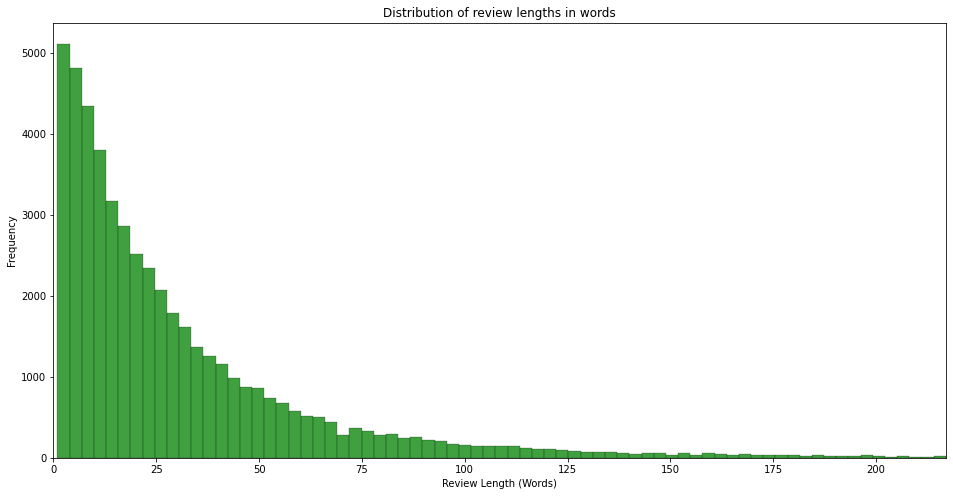

########################################
##   Category: musical_instruments
########################################



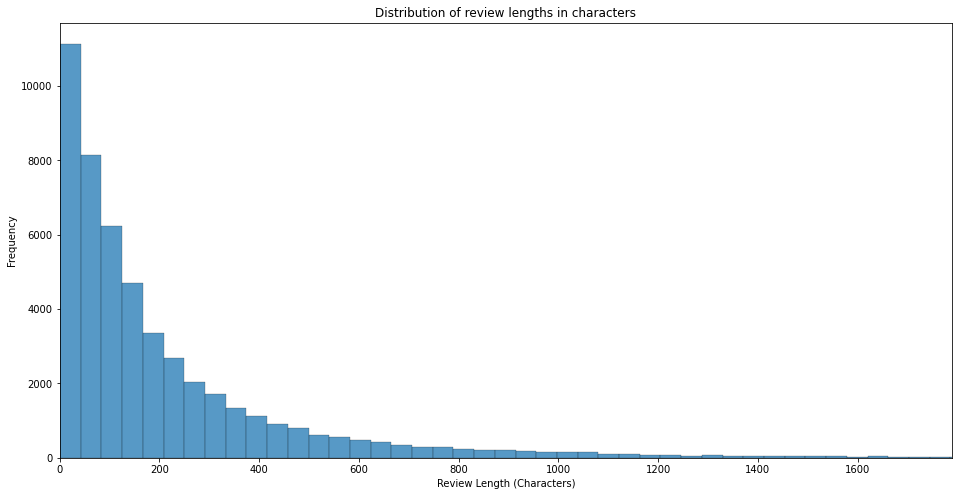

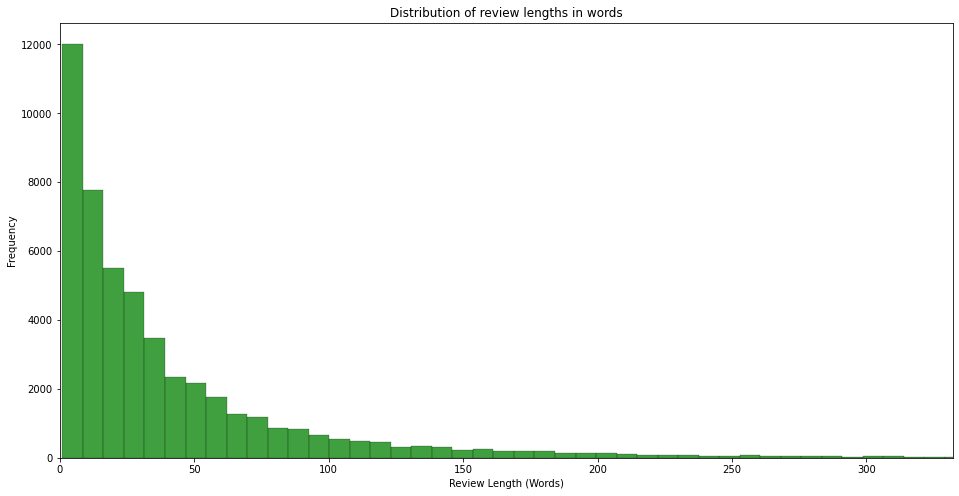

########################################
##   Category: software
########################################



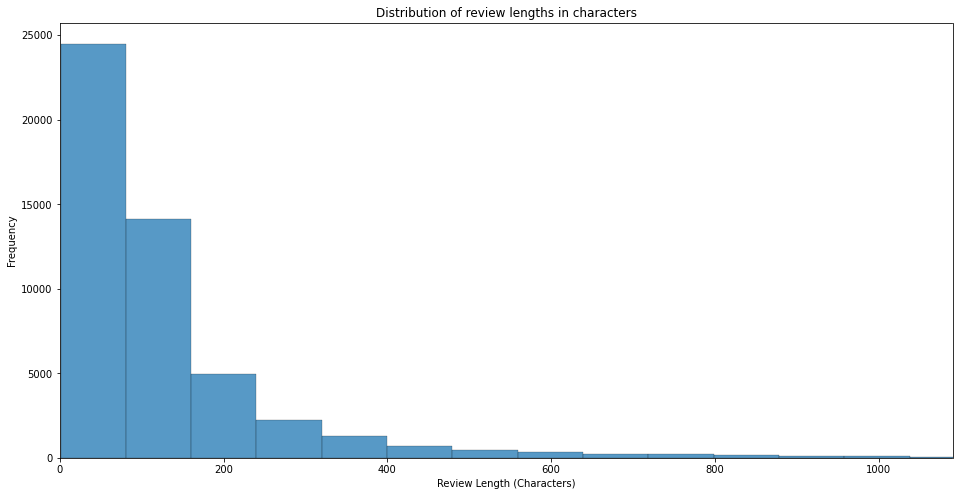

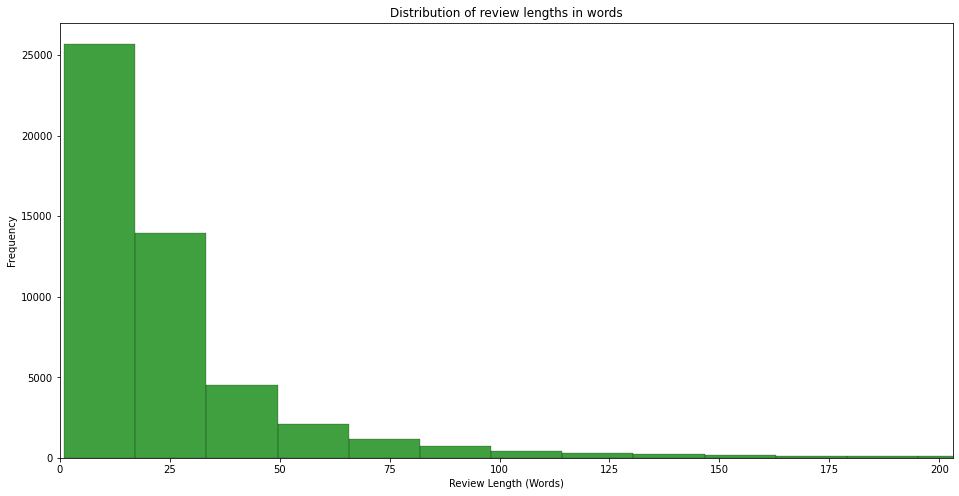

########################################
##   Category: video_games
########################################



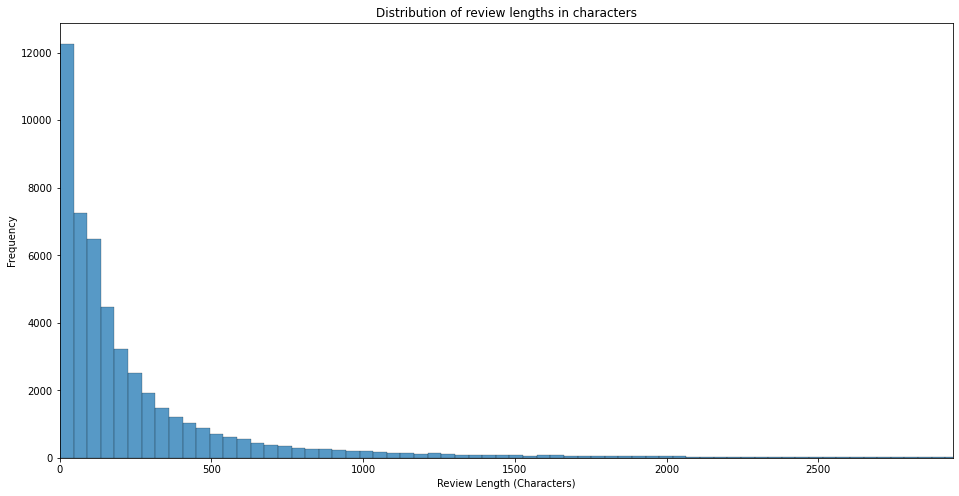

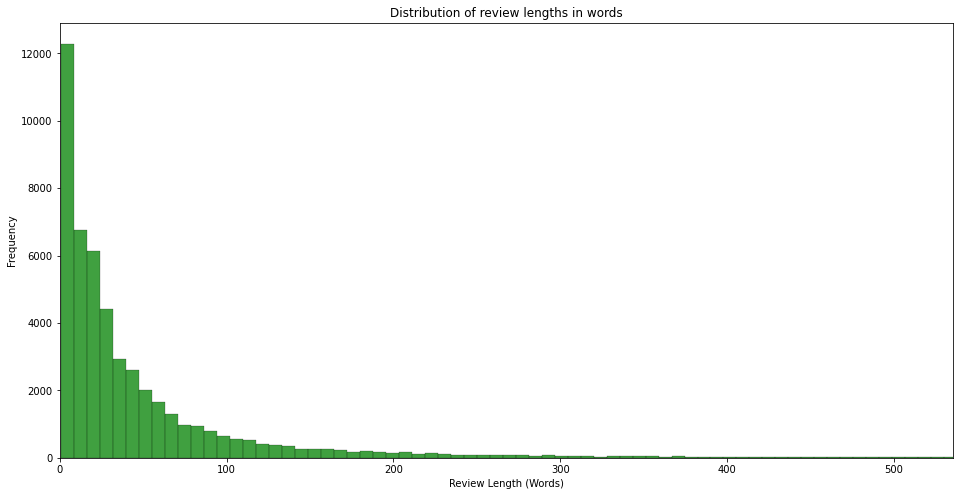

In [11]:
import gc

for category in categories:
    if category not in reviews_dfs: continue
    df = reviews_dfs[category]
    print(f"########################################")
    print(f"##   Category: {category}")
    print(f"########################################\n")

    # downsampling to 50k reviews to optimize memory usage
    # while preserving the statistical distribution.
    df_temp = reviews_dfs[category][['text']].copy()
    df_temp = df_temp.sample(n=50000, random_state=42)
    text_series = df_temp['text'].astype(str)

    char_lengths = text_series.str.len()

    # distribution of reviews lengths (characters)
    plt.figure(figsize=(16,8))
    sns.histplot(char_lengths, bins=400, kde=False)
    plt.xlabel('Review Length (Characters)')
    plt.ylabel('Frequency')
    plt.title('Distribution of review lengths in characters')
    plt.xlim(0, char_lengths.quantile(0.99))
    plt.show()

    # instead of counting the words which takes up too much ram
    # word_lengths = df['text'].astype(str).str.split().str.len()
    # we count the spaces in between which gives us the same result but with far less ram usage
    word_lengths = text_series.str.count(' ') + 1

    # distribution of reviews lengths (words)
    plt.figure(figsize=(16,8))
    sns.histplot(word_lengths, bins=400, kde=False, color='green')
    plt.xlabel('Review Length (Words)')
    plt.ylabel('Frequency')
    plt.title('Distribution of review lengths in words')
    plt.xlim(0, word_lengths.quantile(0.99))
    plt.show()

    del df_temp, text_series, char_lengths, word_lengths
    gc.collect()

We can see that generally all categories seem to have an overall positive appeal on customers. However, it is clear that software has significantly more negative reviews (less that 3.0/5.0) than any other category. We can also see the average review score per category below:

In [12]:
def get_average_rating(df):
    return df['rating'].sum() / df['rating'].size

for category in categories:
    print(f'Average rating for category {category} is: {get_average_rating(reviews_dfs[category])}')

Average rating for category appliances is: 4.221502345432807
Average rating for category beauty is: 3.9602453501499584
Average rating for category musical_instruments is: 4.255534246094122
Average rating for category software is: 3.9350868338694815
Average rating for category video_games is: 4.04745951825179


To continue, we can move on to finding which products with a high review number have low overall ratings. We also show the words that are found most commonly in these products' reviews by wordclouds. 

Top 10 products with high review volume but low ratings for category appliances:
- B01CBWDY0C: Nespresso Capsules Refillable - Reusable Coffee Pods For Nespresso Cups - OriginalLine Compatible - Pack of 6 (reviews: 938, avg rating: 3.00)
- B081K5T5HB: Deflecto Magnetic Vent Cover, For Sidewall and Floor Vents, 5" x 12", 3 Pack (MVCX512),White (reviews: 896, avg rating: 2.51)
- B0000CF4DJ: Harold Coffee Tools Filter Separator (reviews: 749, avg rating: 2.87)
- B08WH5XL86: RCA RFRF450-AMZ, 5.1 Cubic Foot Chest, Deep Freezer Cold Storage for Food, White (reviews: 691, avg rating: 2.77)
- B09JY77GCY: GE Profile Opal | Countertop Nugget Ice Maker with Side Tank | Portable Ice Machine Makes up to 24 lbs. of Ice Per Day | Stainless Steel Finish (reviews: 675, avg rating: 2.85)
- B09B18P5RG: GE Profile Opal | Countertop Nugget Ice Maker | Portable Ice Machine Complete with Bluetooth Connectivity | Smart Home Kitchen Essentials | Stainless Steel Finish | Up to 24 lbs. of Ice Per Day (reviews: 5

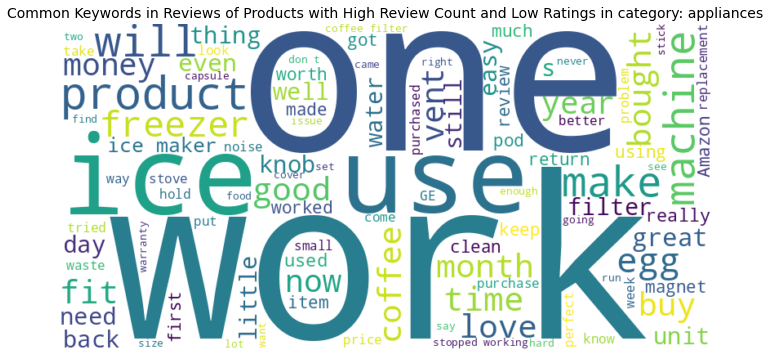

Top 10 products with high review volume but low ratings for category beauty:
- B01195J43I: DASKY 29W Digital Anti Static Ceramic Hair Straightener Heating Detangling Hair Brush Paddle Brush For Faster Straightening Styling Massage Straightening Iron (Pink) (reviews: 502, avg rating: 2.84)
- B082RD77G5: Purple Shampoo and Conditioner Set - Sulfate Free Salon Grade (2 x 16.9 fl oz) - Hydrating Toner - Shimmer Correction for Platinum Blonde, Silver, Light, and Grey Hair (reviews: 478, avg rating: 2.91)
- B071XQ355Y: Tooletries – Oliver Shower Mirror - Premium Shower Mirror for Shaving, Grooming - 100% silicone - SHATTERPROOF Mirror - Grips to Shiny Surfaces - No Suction Cups - No Adhesives – Charcoal (reviews: 448, avg rating: 2.91)
- B01CTQC9J2: CITY 1 PC White Peel Off Liquid Tape Peel Off Base Coat Nail Art Liquid Palisade (reviews: 338, avg rating: 2.78)
- B07WDJB6BH: Allnice Magnetic Eyelashes Dual Magnets False Eyelashes Reusable 3D No Glue 3 Fake Lashes Extension with Tweezers for 

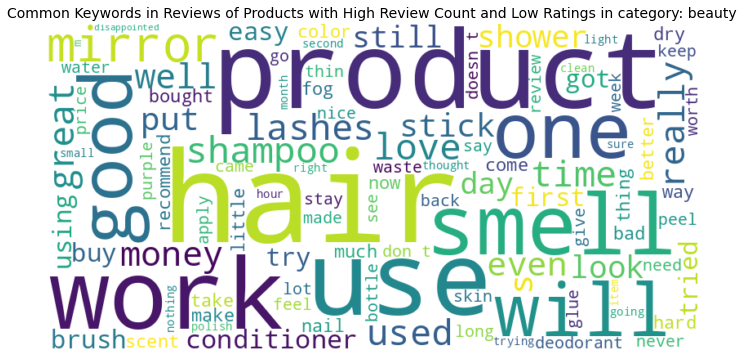

Top 10 products with high review volume but low ratings for category musical_instruments:
- B0007L8BQW: PYLE-PRO Wireless Clip Lavalier Microphone System Portable Professional Clip Lav lapel Mic set with Volume Control, 20 ft range - Transmitter, Receiver, Battery For Camera, Sound Recorder ProPDWM96 (reviews: 1253, avg rating: 2.72)
- B09HZMX75B: Uniwit Mini Portable Vocal/Instrument Microphone for Mobile Phone Laptop Notebook Apple iPhone Sumsung Android with Holder Clip (Golden) (reviews: 1193, avg rating: 2.62)
- B0006DONOK: Emerson EAM-9002 Dual Handheld Wireless Microphone Starter Kit with Wireless FM Receiver, Black (reviews: 391, avg rating: 2.82)
- B00282WZG0: Grover Jaw Harp (8037) (reviews: 357, avg rating: 2.48)
- B00H7Y2ZKK: On Stage MN5A Nylon Tip Maple Drum Sticks (Pack of 12) (reviews: 311, avg rating: 2.94)
- B002UR3JVI: Hello Kitty / Emoji Karaoke Microphone - Style May Vary (reviews: 308, avg rating: 2.55)
- B01G2DLWZU: Ez-Fret Guitar Attachment, Eliminates Finger Pa

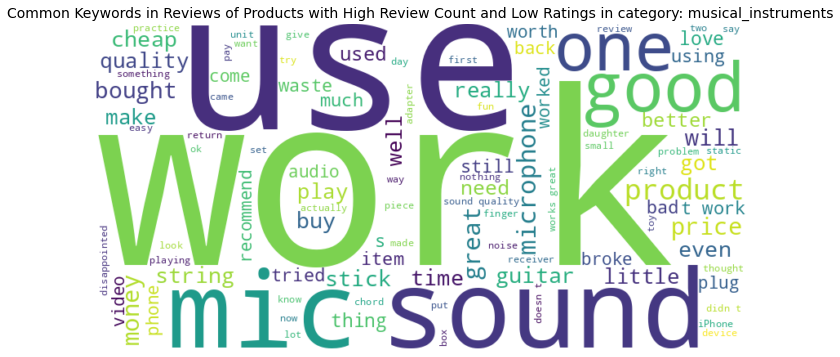

Top 10 products with high review volume but low ratings for category software:
- B017250D16: Paramount+ (reviews: 26026, avg rating: 2.68)
- B00BYJ6BUO: ABC: Watch Live TV & Sports (reviews: 9125, avg rating: 2.93)
- B01923M8T6: NBC Sports (reviews: 7884, avg rating: 2.77)
- B01LXOU5PM: NFL (reviews: 6499, avg rating: 2.89)
- B00E81O27Y: ESPN for Fire TV (reviews: 6185, avg rating: 2.97)
- B019DCHDZK: fuboTV: Watch Live Sports, TV Shows, Movies & News (reviews: 5437, avg rating: 2.88)
- B00KY7PEAA: Game of War - Fire Age (reviews: 5433, avg rating: 2.98)
- B00GY1DWUO: Spectrum TV (reviews: 5306, avg rating: 2.96)
- B019CVAKMK: Paramount Network (reviews: 4687, avg rating: 2.86)
- B00BI60DMU: Watch TBS (reviews: 3987, avg rating: 3.00)


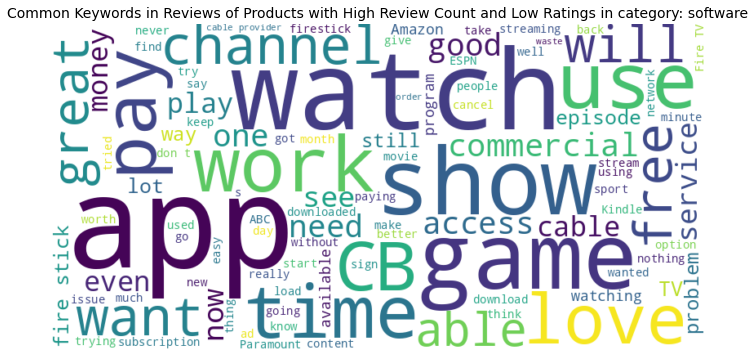

Top 10 products with high review volume but low ratings for category video_games:
- B007W5PG5U: SimCity: Limited Edition (reviews: 3765, avg rating: 1.48)
- B07YBX7Y3P: Fallout 76 - Xbox One Tricentennial Edition (reviews: 3317, avg rating: 2.54)
- B001FRTK4O: Spore - PC/Mac (reviews: 2400, avg rating: 1.82)
- B07DK1H3H5: Cyberpunk 2077 - PC [Game Download Code in Box] (reviews: 2277, avg rating: 2.63)
- B007VTVRFA: SimCity - Standard Edition [Download] (reviews: 2236, avg rating: 1.76)
- B00ZQB28XK: No Man's Sky - PlayStation 4 (reviews: 1876, avg rating: 2.81)
- B0B36T478W: ASTRO Gaming A50 Wireless Headset + Base Station Gen 4 - Compatible With PS5, PS4, PC, Mac - Black/Silver (reviews: 1739, avg rating: 2.96)
- B0BFFJTZNN: SteelSeries Arctis 9X Wireless Gaming Headset – Integrated Xbox Wireless + Bluetooth – 20+ Hour Battery Life – for Xbox One and Series X (reviews: 1731, avg rating: 2.75)
- B09BXPRNY9: Turtle Beach Recon Chat Xbox Headset for Xbox Series X, Xbox Series S, Xbox On

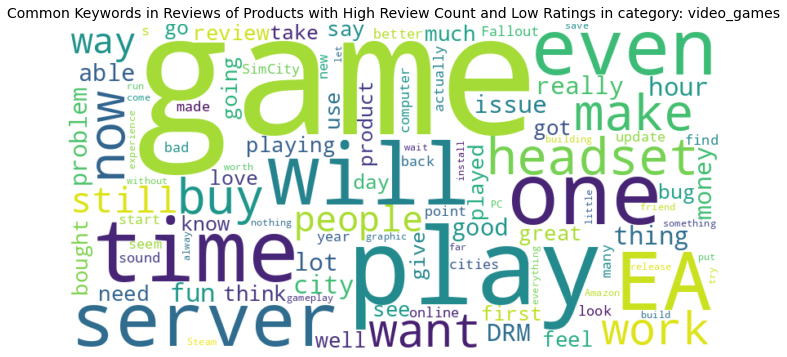

In [14]:
# searching for products with high number of reviews but low average rating
from wordcloud import WordCloud

def high_reviews_low_ratings(category):
    review_df = reviews_dfs[category].copy()
    meta_df = meta_dfs[category].copy()

    # group reviews by parent_asin to calculate number of reviews and average rating
    product_stats = review_df.groupby('parent_asin').agg(
        review_count=('rating', 'count'),
        avg_rating=('rating', 'mean')
    ).reset_index()

    # avoid division by zero by replacing 0 ratings with NaN (they will drop in ratio sorting)
    product_stats = product_stats[product_stats['avg_rating'] > 0]

    # join with meta_df on parent_asin to get product titles
    meta_df_reduced = meta_df[['parent_asin', 'title']]
    merged = product_stats.merge(meta_df_reduced, on='parent_asin', how='left')

    # sort by ratio and keep top N products
    n = 10
    top_products = merged[merged['avg_rating'] < 3].sort_values(by='review_count', ascending=False).head(n)

    # Print titles of top N products
    print(f"Top {n} products with high review volume but low ratings for category {category}:")
    # for now they all will be NaN because there are no matvhing parent-asins between meta and review datasets
    # for 10,000 dataset of appliances, some actual names were shown, so it works
    for i, row in top_products.iterrows():
        print(f"- {row['parent_asin']}: {row['title']} (reviews: {row['review_count']}, avg rating: {row['avg_rating']:.2f})")

    # Get the parent_asins
    top_asins = top_products['parent_asin'].tolist()

    # Extract reviews for top products
    top_reviews = review_df[review_df['parent_asin'].isin(top_asins)]

    # Concatenate all review texts
    all_text = " ".join(top_reviews['text'].dropna().astype(str))

    # Generate WordCloud
    wordcloud = WordCloud(width=800, height=400, background_color='white', max_words=100).generate(all_text)

    plt.figure(figsize=(12, 6))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis("off")
    plt.title(f"Common Keywords in Reviews of Products with High Review Count and Low Ratings in category: {category}", fontsize=14)
    plt.show()

for category in categories:
    high_reviews_low_ratings(category)

### Looking for the best sellers
We aim to find the top_n best selling products from each category. This is based off of the number of reviews each product has, taking into account only the reviews from verified purchases.

In [15]:
def best_selling_products(category, top_n):
    review_df = reviews_dfs[category]
    meta_df = meta_dfs[category]

    # verified purchases only
    verified_reviews = review_df[review_df['verified_purchase'] == True]

    # number of verified reviews per product
    reviews_count = verified_reviews.groupby('parent_asin').size().reset_index(name='verified_review_count')

    # merge with meta data to get products' titles
    merged_df = pd.merge(reviews_count, meta_df[['parent_asin', 'title', 'main_category']], on='parent_asin', how='left')

    # drop duplicates (in case there are duplicates of parent_asin in metadata)
    if meta_df['parent_asin'].duplicated().sum()>0:
        merged_df = merged_df.drop_duplicates(subset=['parent_asin'])

    # sort by verified review count descending and take top_n
    top_products = merged_df.sort_values(by='verified_review_count', ascending=False).head(top_n)

    print(f"\nTop {top_n} best-selling products (based on verified purchases) in category '{category}':\n")
    for idx, row in top_products.iterrows():
        print(f"- {row['title']} (ASIN: {row['parent_asin']} | Verified Reviews: {row['verified_review_count']})")
    print("")


for category in categories:
    best_selling_products(category, 5)


Top 5 best-selling products (based on verified purchases) in category 'appliances':

- 12 Pack Keurig Filter Replacement by K&J - Compatible with Keurig Coffee Machine (2.0 and older) (ASIN: B0B3DB5HTC | Verified Reviews: 11865)
- iPartPlusMore Reusable Coffee Filters Compatible with 1.0 and 2.0 Keurig Single Cup Coffee Maker - BPA-Free Stainless Steel Refillable K Cup Coffee Filter with Fine Mesh Screen (Pack of 4) (ASIN: B07RNJY499 | Verified Reviews: 11416)
- Linda's Essentials Silicone Stove Gap Covers (2 Pack), Heat Resistant Oven Gap Filler Seals Gaps Between Stovetop and Counter, Easy to Clean (25 Inches, White) (ASIN: B07WTXWC32 | Verified Reviews: 8412)
- SAMSUNG Genuine Filters for Refrigerator Water and Ice, Carbon Block Filtration for Clean, Clear Drinking Water, DA29-00020B-3P, 3 Pack (ASIN: B08YBGCNHP | Verified Reviews: 7195)
- GE MWF Refrigerator Water Filter | Certified to Reduce Lead, Sulfur, and 50+ Other Impurities | Replace Every 6 Months for Best Results | Pack o

Let's now see how the average product ratings have changed over time:

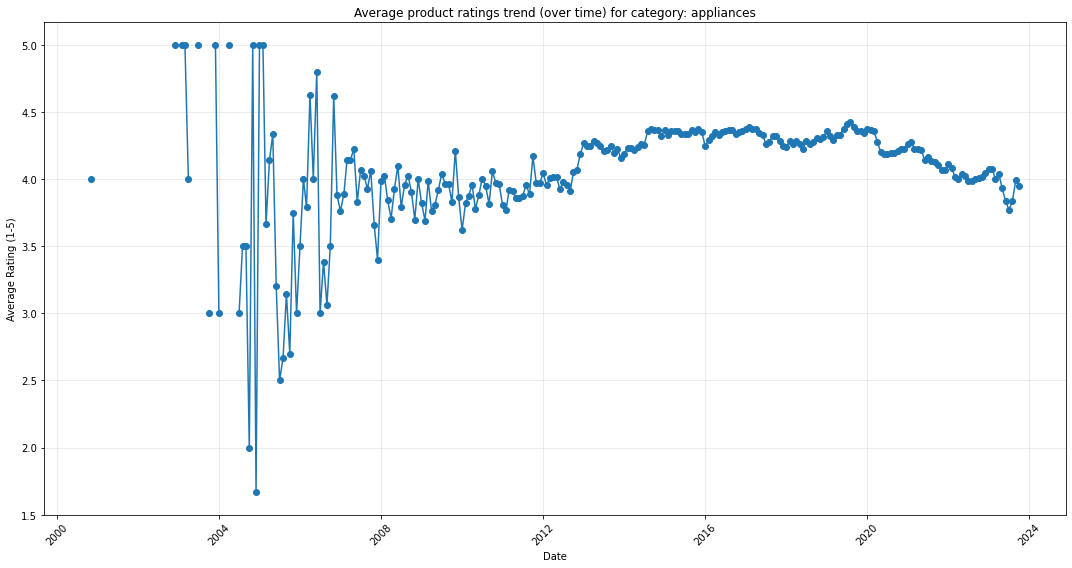

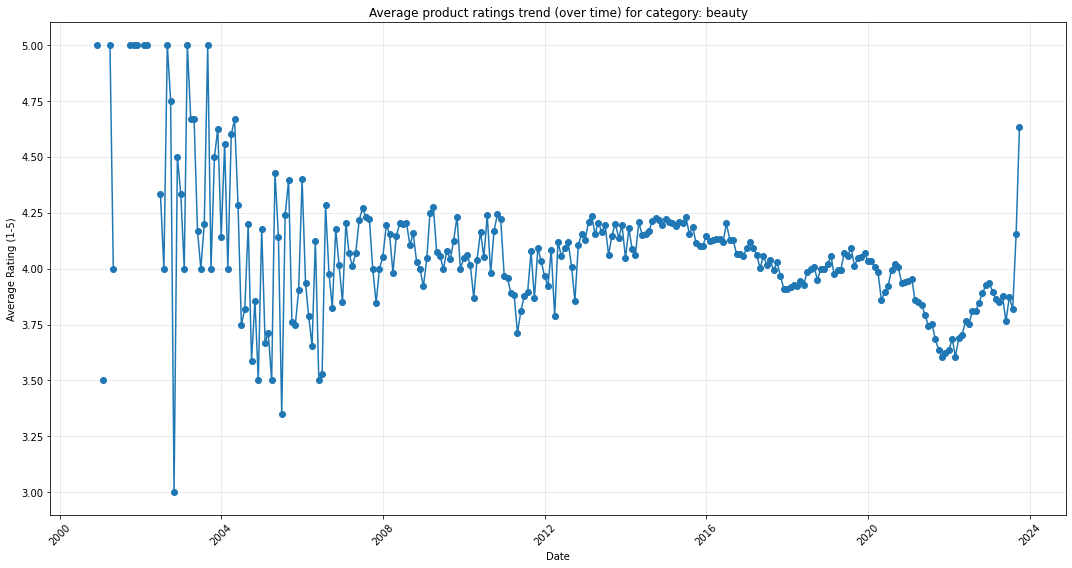

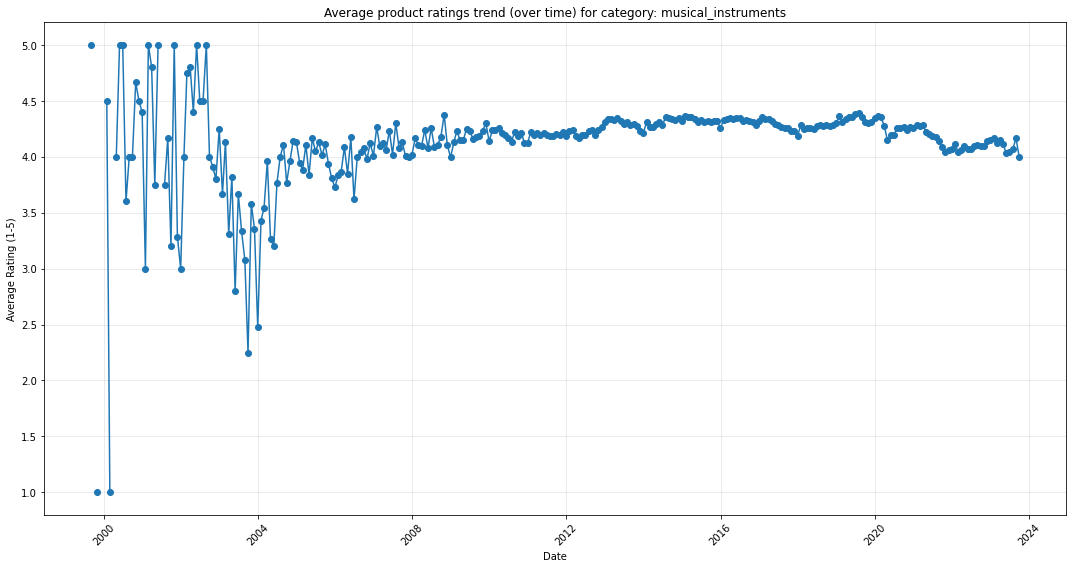

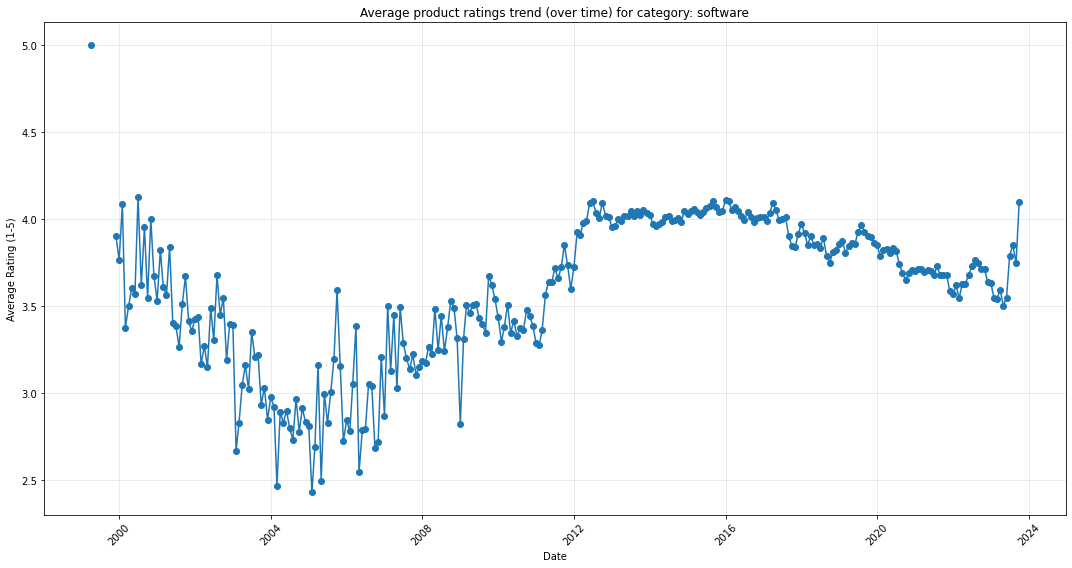

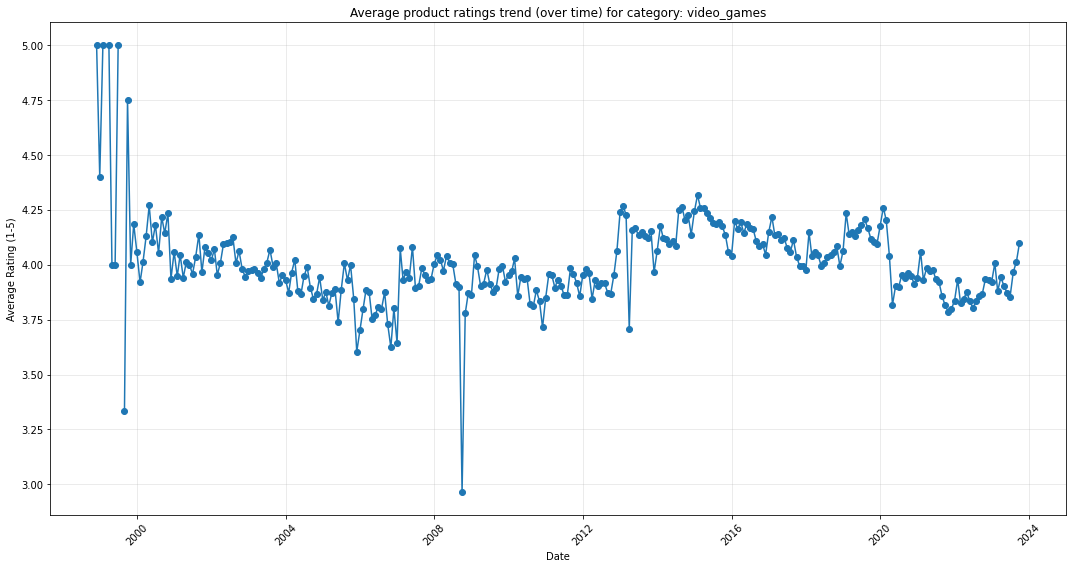

In [16]:
for category in categories:
    (reviews_dfs[category])['timestamp'] = pd.to_datetime((reviews_dfs[category])['timestamp'], unit='ms')

for category in categories:
    df = reviews_dfs[category]

    # Resample by month and calculate mean ratings
    monthly_avg = (df.set_index('timestamp').resample('ME')['rating'].mean().reset_index())

    plt.figure(figsize=(15, 8))
    plt.plot(monthly_avg['timestamp'], monthly_avg['rating'], marker='o', linestyle='-')
    
    plt.title(f'Average product ratings trend (over time) for category: {category}')
    plt.xlabel('Date')
    plt.ylabel('Average Rating (1-5)')
    plt.grid(True, alpha=0.3)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


As we can see, there aren't any noticeable patterns - but that might be because of our limited dataset size. We can see that there were far too little reviews before 2012 for almost all the categories (which is expected, as not many people were using the internet on a daily basis). 

However, video game reviews have been quite consistent in their number. That is of course expected, as people who play video games were more used to being on the internet (while playing games :D), and therefore would write more reviews.

### Task 2: Feature Engineering with Sentiment Scores and Ratings

In this task, our aim is to extract a sentiment score for the reviews, indicating how positive or how negative each review is. Then we associate this score with the respective rating(scaling 0-5). The heatmaps provided below showcase exactly this correlation: how many instances, had ratings(scaling 0-5) that matched the user's review in terms of sentiment(satisfaction/dissatisfaction).

In [17]:
# extracting and adjusting sentiment score from reviews

from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import numpy as np

analyzer = SentimentIntensityAnalyzer()

def compute_vader_sentiment(text):
    if pd.isna(text):
        return 0.0
    # we can limit input strigns to 10000 characters for speeding up,
    # as vader rarely uses more than 200-300 words to extract sentiment
    # return analyzer.polarity_scores(str(text)[:10000])['compound']
    return analyzer.polarity_scores(text)['compound']

for category in categories:
    print(f"#################################################")
    print("##")
    print(f"##       Category: {category}")
    print("##")
    print(f"#################################################")
    df = reviews_dfs[category].copy()
    df['vader_sentiment'] = df['text'].apply(compute_vader_sentiment)
    df['adjusted_sentiment'] = df['vader_sentiment']
    
    # add 0.2 where rating >= 4
    df.loc[df['rating'] >= 4, 'adjusted_sentiment'] += 0.2
    # subtract 0.2 where rating <= 2
    df.loc[df['rating'] <= 2, 'adjusted_sentiment'] -= 0.2
    # only keep values between -1 and 1
    df['adjusted_sentiment'] = df['adjusted_sentiment'].clip(lower=-1.0, upper=1.0)

    conditions = [
        (df['adjusted_sentiment'] >= 0.33333),
        (df['adjusted_sentiment'] <= -0.33333)
    ]
    choices = ['positive', 'negative']
    
    # if sentiment is neither positive nor negative, it's neutral
    df['final_sentiment'] = np.select(conditions, choices, default='neutral')
    
    # save back to dataframe
    reviews_dfs[category] = df

    print("Few results of sentiment extraction-adjustment-labelling:")
    print(df[['rating', 'vader_sentiment', 'adjusted_sentiment', 'final_sentiment']].head())
    print("\n\n")

#################################################
##
##       Category: appliances
##
#################################################
Few results of sentiment extraction-adjustment-labelling:
   rating  vader_sentiment  adjusted_sentiment final_sentiment
0     5.0           0.6249              0.8249        positive
1     5.0           0.0000              0.2000         neutral
2     5.0           0.0000              0.2000         neutral
3     5.0           0.9548              1.0000        positive
4     5.0           0.4404              0.6404        positive



#################################################
##
##       Category: beauty
##
#################################################
Few results of sentiment extraction-adjustment-labelling:
   rating  vader_sentiment  adjusted_sentiment final_sentiment
0     5.0           0.8162              1.0000        positive
1     4.0           0.7783              0.9783        positive
2     5.0           0.8070              1.0000

/tmp/ipykernel_7831/3600102680.py:19: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  heatmap_data = df.pivot_table(index='sentiment_bin', columns='rating', aggfunc='size', fill_value=0)


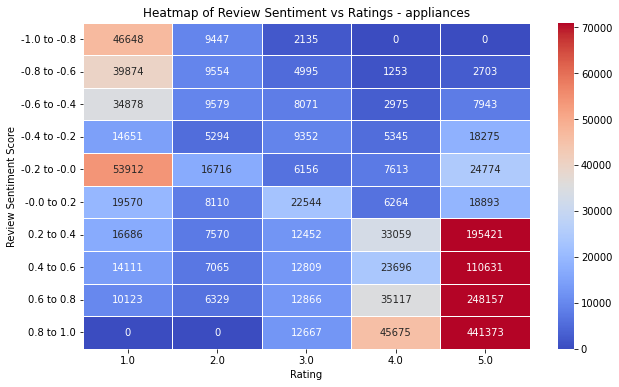

/tmp/ipykernel_7831/3600102680.py:19: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  heatmap_data = df.pivot_table(index='sentiment_bin', columns='rating', aggfunc='size', fill_value=0)


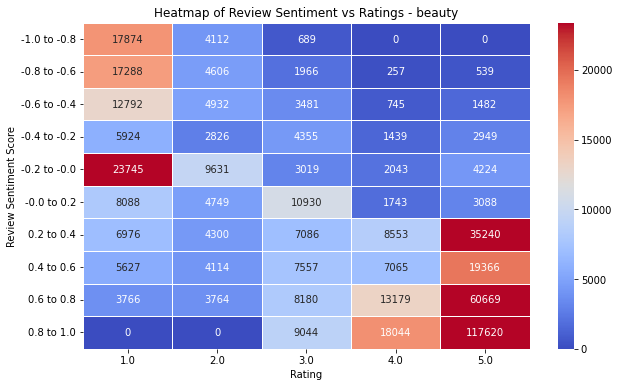

/tmp/ipykernel_7831/3600102680.py:19: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  heatmap_data = df.pivot_table(index='sentiment_bin', columns='rating', aggfunc='size', fill_value=0)


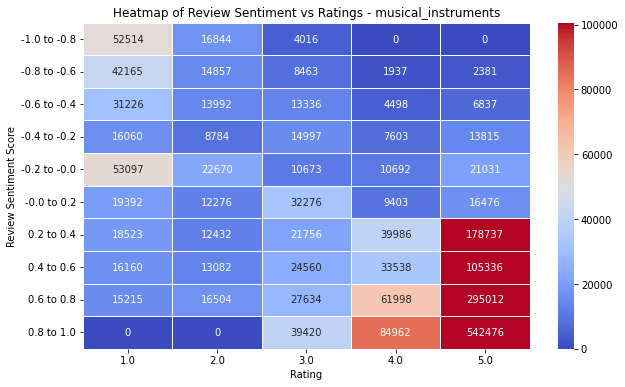

/tmp/ipykernel_7831/3600102680.py:19: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  heatmap_data = df.pivot_table(index='sentiment_bin', columns='rating', aggfunc='size', fill_value=0)


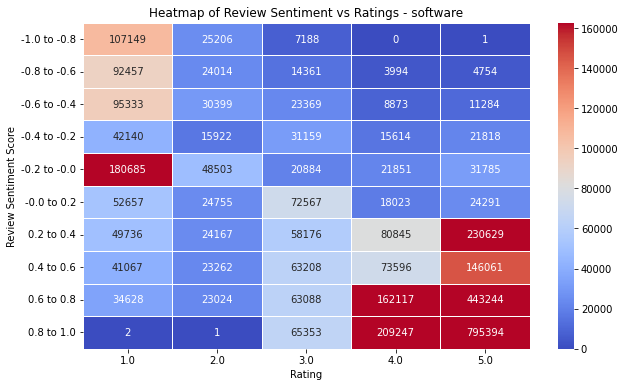

/tmp/ipykernel_7831/3600102680.py:19: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  heatmap_data = df.pivot_table(index='sentiment_bin', columns='rating', aggfunc='size', fill_value=0)


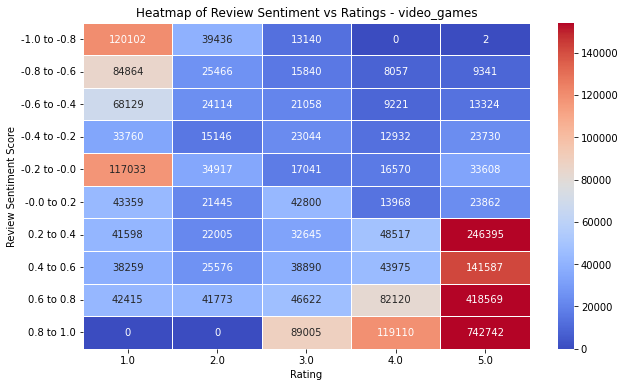

: 

In [ ]:
##################################################################
###                                                            ###
###          HEATMAP FOR SENTIMENT SCORE/RATING SCORE          ###
###                                                            ###
##################################################################

# define sentiment bins (-1 to 1 in steps of 0.2)
bins = np.arange(-1, 1.1, 0.2)
bin_labels = [f"{round(bins[i], 1)} to {round(bins[i+1], 1)}" for i in range(len(bins) - 1)]

for category in categories:
    df = reviews_dfs[category].copy()

    # bin the stored final sentiment scores
    df['sentiment_bin'] = pd.cut(df['adjusted_sentiment'], bins=bins, labels=bin_labels, include_lowest=True)

    # create pivot table: count of reviews for each (rating, sentiment_bin) pair
    # necessary for the heat map
    heatmap_data = df.pivot_table(index='sentiment_bin', columns='rating', aggfunc='size', fill_value=0)

    plt.figure(figsize=(10, 6))
    # vmax is max_rows/20 so that a good color distribution is achieved
    # if it was a lot higher (e.g.max_rows/2) most blocks of the map would have almost the same color
    sns.heatmap(heatmap_data, cmap='coolwarm', annot=True, fmt='d', linewidths=.5, vmin=0, vmax=len(df)/30)
    plt.title(f'Heatmap of Review Sentiment vs Ratings - {category}')
    plt.xlabel('Rating')
    plt.ylabel('Review Sentiment Score')
    plt.show()

Results make sense as the heatmap is "hot" south-east and north-west, because more "extreme" ratings tend to be well articulated and explained in the respective review. On the contrary, the heatmap is "cold" south-west and north-east because in very few cases, a review is completely opposite to the respective rating. For example, there could be mistakes in ratings: a positive review for a good product but a 1-star rating by accident. We can see a higher concentration of ratings in positive ratings with a very high sentiment score, simply because in all categories, there are overall way more positive than negative ratings.